# 🎬 TMDB Movie Analytics — EDA Empresarial
**Máster en Data Science & AI · Proyecto Entregable**

---

## Objetivo
Responder 5 preguntas de negocio sobre la industria cinematográfica usando datos de TMDB:

| ID | Pregunta | Visualización |
|----|----------|---------------|
| Q1 | ¿Qué géneros tienen mayor ROI (Retorno Sobre la Inversión) y beneficio absoluto históricamente? | Barras horizontales |
| Q2 | ¿Cómo ha evolucionado la cuota de producción de cada género por décadas? | Mapa de calor |
| Q3 | ¿Más presupuesto garantiza más recaudación? ¿Varía por género? | Scatter log-log |
| Q4 | ¿Las películas mejor valoradas son también las más rentables? | Scatter + tendencia |
| Q5 | ¿Qué géneros están en auge y podrían dominar la próxima década? | Líneas temporales |

**Dataset:** [TMDB Movie Data — Kaggle](https://www.kaggle.com/datasets/kakarlaramcharan/tmdb-data-0920)  
~120 000 películas con presupuesto, recaudación, géneros, valoraciones y fechas.


## 1. Setup — Importaciones y configuración

In [19]:
import sys, warnings
sys.path.insert(0, "..")   # permite importar src/ desde notebooks/
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from IPython.display import display

from src.config   import RAW_PATH, OUT_PATH, FIG_PATH
from src.io       import load_csv, export_csv, parse_genre_list
from src.cleaning import clean
from src.features import build_features
from src.viz      import (plot_roi_by_genre, plot_genre_decade_heatmap,
                          plot_budget_vs_revenue, plot_rating_vs_roi, plot_genre_trends)

print(f"  RAW_PATH : {RAW_PATH}")
print(f"  OUT_PATH : {OUT_PATH}")
print(f"  FIG_PATH : {FIG_PATH}")


  RAW_PATH : C:\Users\ferlo\Documents\evolve\MoviesEDA_FernandoLopezSanchez_DataScienceIA\data\raw\movie_data_tmbd.csv
  OUT_PATH : C:\Users\ferlo\Documents\evolve\MoviesEDA_FernandoLopezSanchez_DataScienceIA\data\processed\clean_dataset.csv
  FIG_PATH : C:\Users\ferlo\Documents\evolve\MoviesEDA_FernandoLopezSanchez_DataScienceIA\figures


## 2. Cargar el archivo CSV
El dataset usa **separador `|`** y contiene líneas mal formadas (overviews multilínea).
`load_csv()` usa `engine='python'` con `on_bad_lines='skip'` para tolerarlas.


In [20]:
file_path = RAW_PATH   # data/raw/movie_data_tmbd.csv

df_raw = load_csv(file_path)
print(f"Dimensiones crudas: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
display(df_raw[["title","budget","revenue","genres","vote_average","release_date"]].head(5))


Dimensiones crudas: 119,938 filas × 27 columnas


,title,budget,revenue,genres,vote_average,release_date
0,The Elusive Corporal,0,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",5.9,1962-05-23
1,Sundays and Cybele,0,0,"[{'id': 18, 'name': 'Drama'}]",7.4,1962-11-12
2,Lonely Are the Brave,0,0,"[{'id': 18, 'name': 'Drama'}, {'id': 37, 'name...",7.5,1962-05-24
3,F for Fake,0,0,"[{'id': 99, 'name': 'Documentary'}]",7.5,1975-03-12
4,Long Day's Journey Into Night,500000,0,"[{'id': 18, 'name': 'Drama'}, {'id': 36, 'name...",6.9,1962-10-09


In [21]:
# Tipos de datos en crudo (todo str para evitar errores, mas tarde se transformarán a numéricos o fechas)
df_raw.dtypes.to_frame("dtype").T


,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,...,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,cast,directors
dtype,str,str,str,str,str,str,str,str,str,str,...,str,str,str,str,str,str,str,str,str,str


## 3. Exploración inicial (EDA)
Antes de limpiar: entender nulos, rangos y distribuciones para decidir qué transformar.


In [22]:
# Nulos por columna
null_pct = df_raw.isnull().mean().sort_values(ascending=False) * 100
null_pct = null_pct[null_pct > 0]
print("Columnas con valores nulos (%):")
print(null_pct.round(2).to_string())


Columnas con valores nulos (%):
belongs_to_collection    92.09
homepage                 83.21
tagline                  67.22
backdrop_path            44.07
imdb_id                   4.55
overview                  2.83
release_date              1.08
runtime                   0.99
spoken_languages          0.99
title                     0.99
video                     0.99
cast                      0.99
vote_count                0.99
directors                 0.99
vote_average              0.99
status                    0.99
poster_path               0.72
popularity                0.72
revenue                   0.72
production_companies      0.72
production_countries      0.72
budget                    0.45
original_title            0.45
genres                    0.45
id                        0.45
original_language         0.45


In [23]:
# Muestra de la columna 'genres' (formato JSON-like)
print("Ejemplo de columna 'genres':")
df_raw["genres"].dropna().head(3).tolist()


Ejemplo de columna 'genres':


["[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'name': 'Drama'}, {'id': 10752, 'name': 'War'}]",
 "[{'id': 18, 'name': 'Drama'}]",
 "[{'id': 18, 'name': 'Drama'}, {'id': 37, 'name': 'Western'}]"]

In [24]:
# Distribución de status
df_raw["status"].value_counts().head(10)


status
Released           118743
In Production           5
Post Production         4
Name: count, dtype: int64

## 4. Limpieza y transformaciones
Pipeline de limpieza modularizado en `src/cleaning.py`.

**Problemas identificados y solución:**

| Problema | Solución |
|----------|----------|
| Todos los tipos en `str` | `cast_numeric()` → convierte budget, revenue, etc. |
| `genres` en formato JSON-like como string | `expand_genres()` → lista Python + `primary_genre` |
| Columna `release_date` como texto | `parse_dates()` → datetime + `release_year` + `decade` |
| Duplicados por `id` TMDB | `remove_duplicates()` → keep first |
| Películas no estrenadas o sin votos suficientes | `filter_valid()` → status=Released, votes≥20 |
```


In [25]:
df = clean(df_raw)
print(f"\nShape final: {df.shape}")
display(df[["title","release_year","decade","primary_genre","genre_list",
            "budget","revenue","vote_average","vote_count"]].head(5))


[cleaning] Duplicados eliminados: 851
[cleaning] Filtrado válido: 119,087 → 29,812 filas
[cleaning] Dataset limpio: 29,812 películas listas para análisis

Shape final: (29812, 31)


,title,release_year,decade,primary_genre,genre_list,budget,revenue,vote_average,vote_count
1,Sundays and Cybele,1962,1960s,Drama,[Drama],0.0,0.0,7.4,28.0
2,Lonely Are the Brave,1962,1960s,Drama,"[Drama, Western]",0.0,0.0,7.5,70.0
3,F for Fake,1975,1970s,Documentary,[Documentary],0.0,0.0,7.5,178.0
4,Long Day's Journey Into Night,1962,1960s,Drama,"[Drama, History]",500000.0,0.0,6.9,32.0
7,The Hanging Tree,1959,1950s,Western,[Western],0.0,0.0,6.6,47.0


In [26]:
# Estadísticos descriptivos tras limpieza
df[["budget","revenue","vote_average","vote_count","runtime"]].describe().round(2)


,budget,revenue,vote_average,vote_count,runtime
count,2.981200e+04,2.981200e+04,29812.00,29812.00,29812.00
mean,7.423079e+06,2.033929e+07,6.27,428.97,103.12
std,2.287739e+07,8.945205e+07,0.99,1363.39,23.92
min,0.000000e+00,0.000000e+00,1.10,20.00,60.00
25%,0.000000e+00,0.000000e+00,5.70,32.00,90.00
50%,0.000000e+00,0.000000e+00,6.40,65.00,98.00
75%,2.300000e+06,8.808002e+05,7.00,212.00,111.00
max,3.800000e+08,2.797801e+09,9.50,27088.00,902.00


## 5. Ingeniería de Features
Tres features que serán usadas para los analisis mas adelante:

| Feature | Definición | Uso |
|---------|-----------|-----|
| `roi` | (revenue − budget) / budget | Rentabilidad relativa |
| `profit_M` | (revenue − budget) / 1M | Beneficio absoluto en M$ |
| `rating_tier` | Cuartiles de vote_average | Segmentación de calidad |


In [27]:
df = build_features(df)

# Vista de las features
mask = df["roi"].notna()
print(f"Películas con ROI calculable: {mask.sum():,}")
display(df[mask][["title","primary_genre","budget","revenue","roi","profit_M","rating_tier"]].head(8))


[features] ROI calculado para 6,361 películas con datos financieros completos
[features] Rating tiers: {'Bueno': 10760, 'Medio': 10518, 'Bajo': 5602, 'Excelente': 2932}
Películas con ROI calculable: 6,361


,title,primary_genre,budget,revenue,roi,profit_M,rating_tier
10,Taras Bulba,Adventure,7000000.0,4000000.0,-0.428571,-3.000000,Bueno
35,Never on Sunday,Drama,151000.0,8000000.0,51.980132,7.849000,Bueno
54,Ghostbusters,Action,144000000.0,229147509.0,0.591302,85.147509,Bajo
67,Roadgames,Horror,1750000.0,100000.0,-0.942857,-1.650000,Bueno
85,The Killer Shrews,Horror,123000.0,1000000.0,7.130081,0.877000,Bajo
164,I Was a Teenage Werewolf,Drama,82000.0,2000000.0,23.390244,1.918000,Bajo
186,Friendly Persuasion,Drama,3000000.0,8000000.0,1.666667,5.000000,Medio
192,How Green Was My Valley,Drama,1250000.0,6000000.0,3.800000,4.750000,Bueno


In [28]:
# Distribución del ROI (percentil 5-95 para evitar outliers)
roi_data = df[df["roi"].notna()]["roi"]
print(f"ROI mediano global  : {roi_data.median():.2f}×")
print(f"ROI medio global    : {roi_data.mean():.2f}×")
print(f"ROI p5 / p95        : {roi_data.quantile(0.05):.2f} / {roi_data.quantile(0.95):.2f}")
print(f"% películas rentables: {(roi_data > 0).mean()*100:.1f}%")


ROI mediano global  : 1.07×
ROI medio global    : 7.90×
ROI p5 / p95        : -0.91 / 14.21
% películas rentables: 70.9%


In [29]:
# Distribución de rating_tier
print("Distribución de Rating Tier:")
print(df["rating_tier"].value_counts().sort_index())


Distribución de Rating Tier:
rating_tier
Bajo          5602
Medio        10518
Bueno        10760
Excelente     2932
Name: count, dtype: int64


## 6. Visualizaciones de Negocio
Cinco gráficos para responder a las preguntas planteadas desde diferentes ángulos.


### Q1 — ¿Qué géneros tienen mayor ROI y beneficio absoluto históricamente?
Usamos la **mediana** tanto del ROI como del beneficio absoluto (M$) en lugar de la media,
para ser robustos frente a blockbusters atípicos que distorsionarían el resultado.
El gráfico combina ambas métricas en una sola barra: el ROI (%) refleja la eficiencia
relativa de la inversión, mientras que el beneficio neto (M$) muestra el volumen
real de dinero generado.

[viz] Guardado → C:\Users\ferlo\Documents\evolve\MoviesEDA_FernandoLopezSanchez_DataScienceIA\figures\Q1_roi_by_genre.png


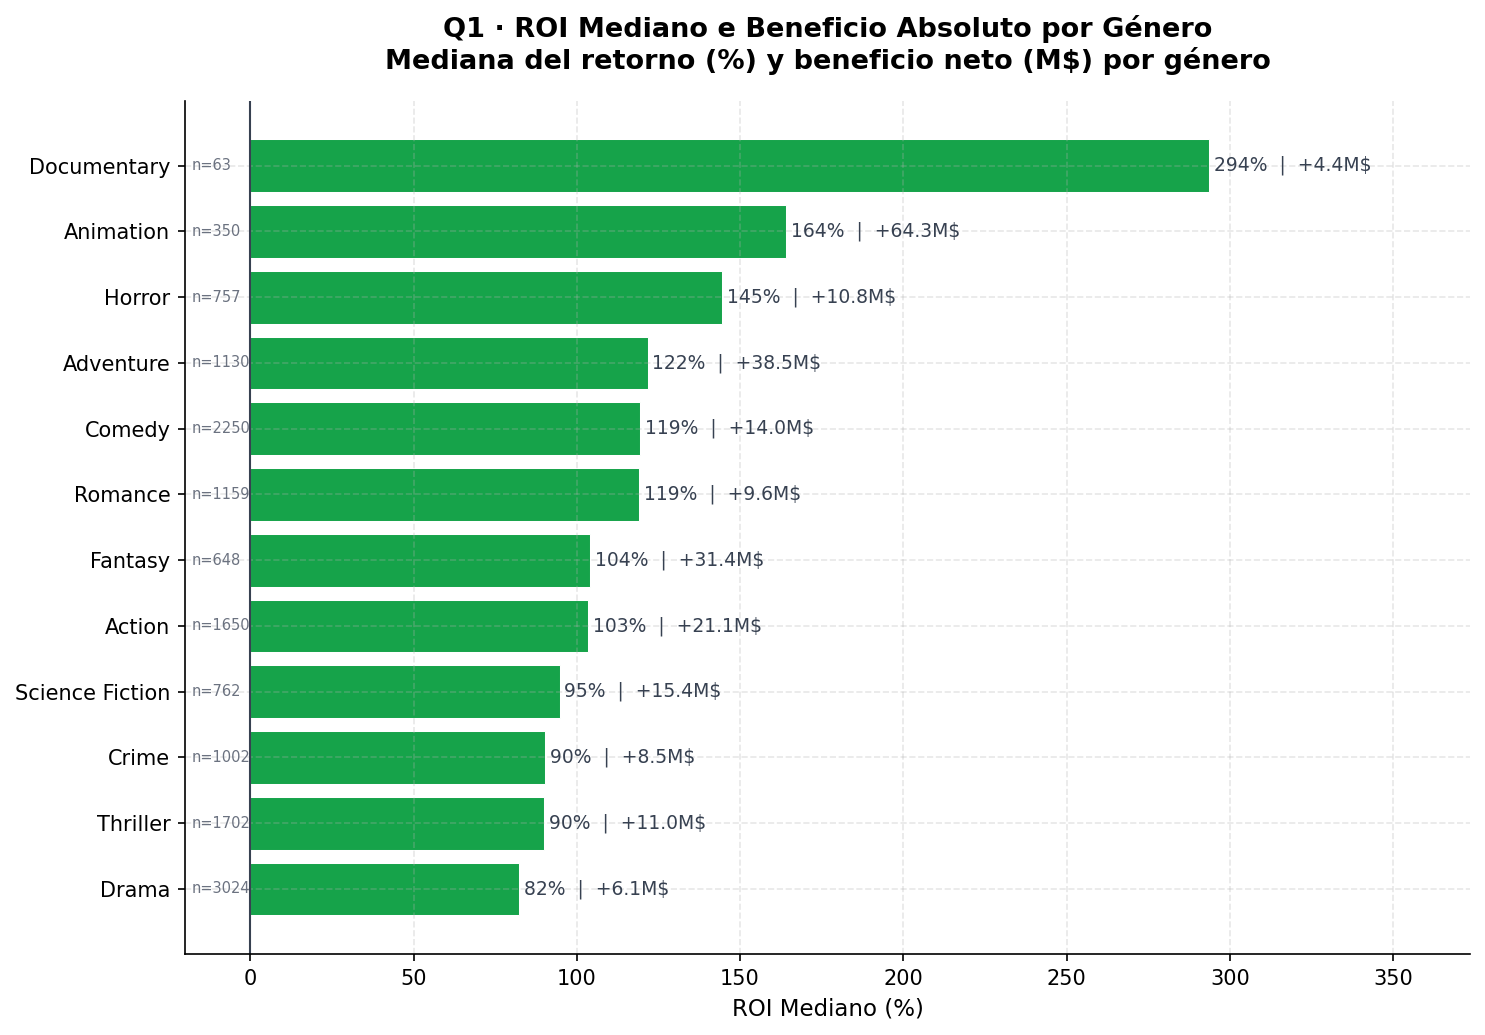

In [30]:
fig1 = plot_roi_by_genre(df)
plt.show()


**Interpretación:** Lo primero que hay que tener en cuenta es que un ROI del 80% no es perder
un 20% de la inversión. Un ROI del 0% significa recuperar al 100% lo invertido, con lo cual
que una película (o en este caso la mediana de un género) tenga un ROI del 80% significa que
si por ejemplo han invertido 100€ han ganado con ella 180€.

Ahora, entendiendo esto, ya podemos comentar claramente el gráfico resultante. Cada barra
muestra dos datos: el ROI (%) a la izquierda y el beneficio neto absoluto (M$) a la derecha
separado por un "|".

Para empezar podemos decir claramente que todos los grandes géneros del cine son rentables,
pero a la hora de tratarlos individualmente hay que estar atentos. Documentary lidera en ROI
con 294% pero su muestra pequeña (n=63) lo hace poco fiable. Animation y Horror combinan ROI
alto con beneficio absoluto relevante, confirmándolos como la apuesta más sólida.

El dato más interesante surge al comparar ambas métricas: un género puede tener ROI alto pero
mover poco dinero en términos absolutos (como Documentary), mientras que Action o Adventure,
con ROI más moderado, generan beneficios netos en M$ mucho mayores por el volumen de sus
producciones. Dependiendo del perfil del inversor, eficiencia vs volumen, la elección
óptima de género cambia.

### Q2 — ¿Cómo ha evolucionado la cuota de producción por género y décadas?
Cada celda muestra el **% de películas de ese género en esa década** respecto al total.


[viz] Guardado → C:\Users\ferlo\Documents\evolve\MoviesEDA_FernandoLopezSanchez_DataScienceIA\figures\Q2_genre_decade_heatmap.png


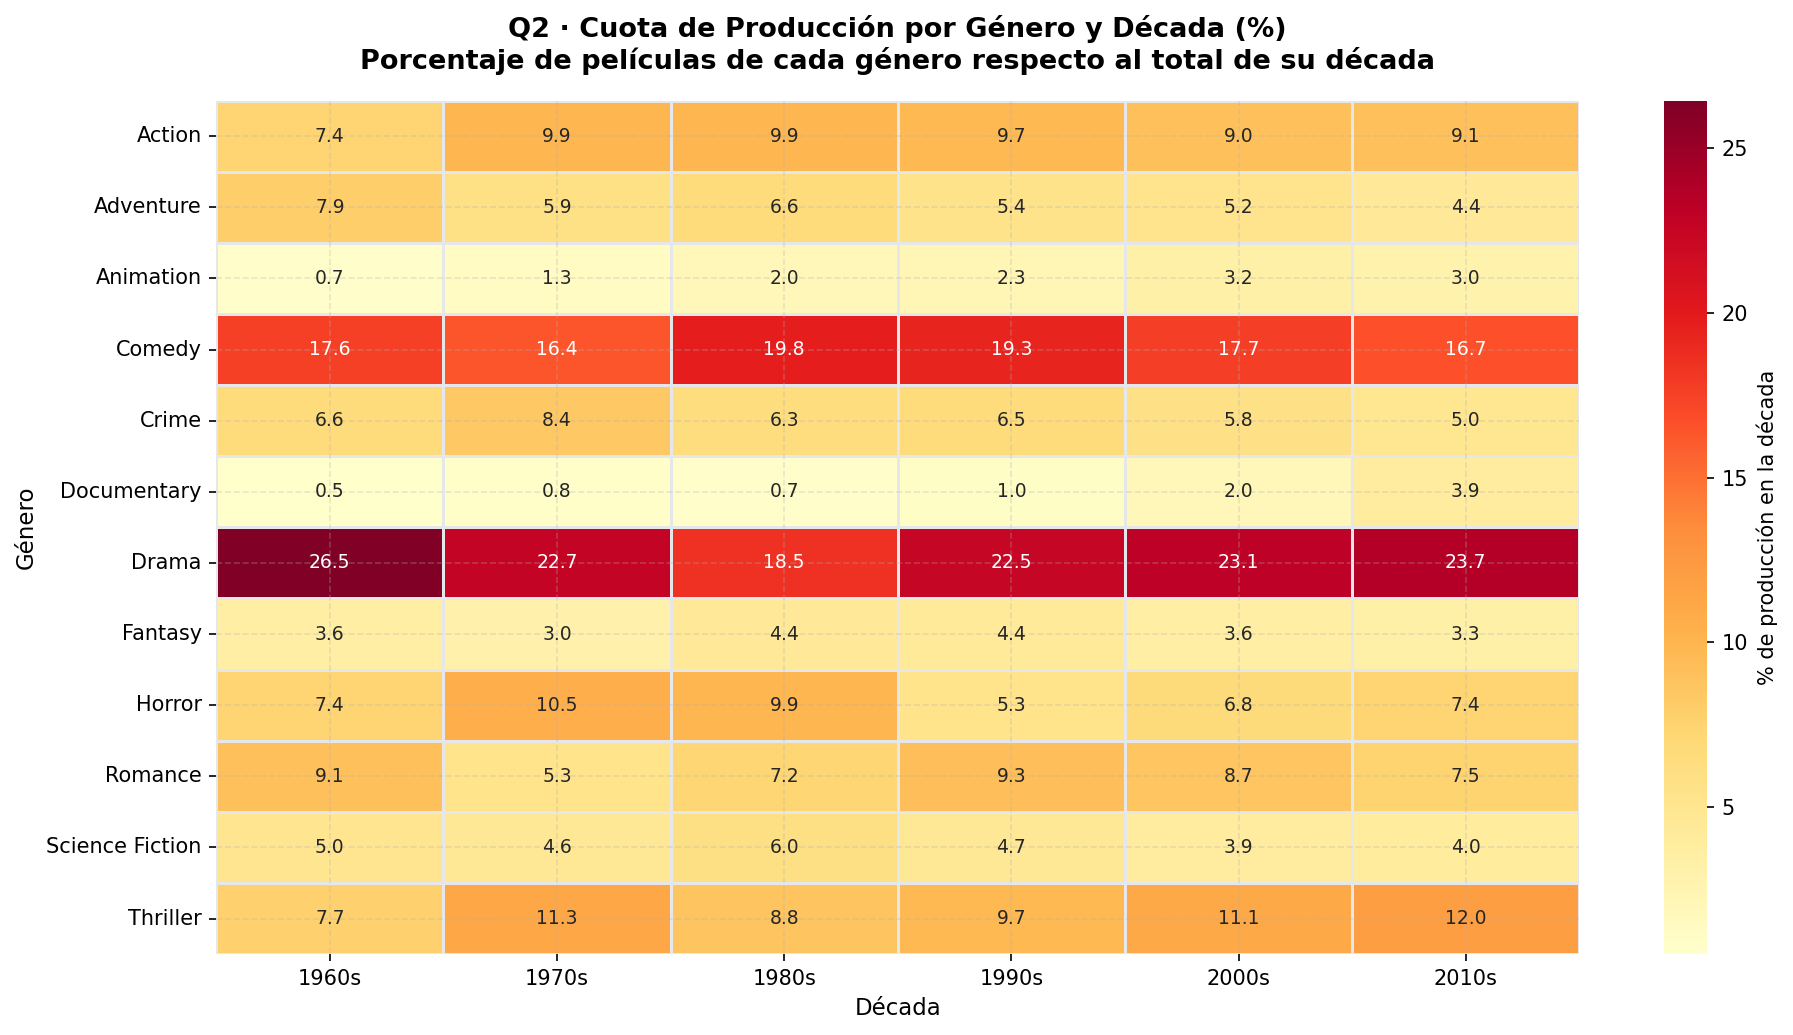

In [31]:
fig2 = plot_genre_decade_heatmap(df)
plt.show()


**Interpretación:** Drama domina en todas las décadas pero con una caída notable del 26.5% en los 60s al 18.5% en los 80s, recuperándose después hasta el 23.7% en los 2010s. Comedy se mantiene sorprendentemente estable entre el 16-19% durante 60 años, lo que indica una demanda estructural del mercado independiente de modas.

El dato más llamativo es Animation: pasa del 0.7% en los 60s al 3.0% en los 2010s, cuadruplicando su cuota. Combinado con su ROI del 164% en Q1, es el género con mayor recorrido de crecimiento sostenido. Thriller también crece de forma consistente del 7.7% al 12.0%, consolidándose como uno de los géneros emergentes de las últimas décadas.


### Q3 — ¿Más presupuesto garantiza más recaudación?
Scatter log-log con la diagonal como referencia de break-even (ROI = 0).
Puntos **sobre** la diagonal = rentables; **bajo** = pérdidas.


[viz] Guardado → C:\Users\ferlo\Documents\evolve\MoviesEDA_FernandoLopezSanchez_DataScienceIA\figures\Q3_budget_vs_revenue.png


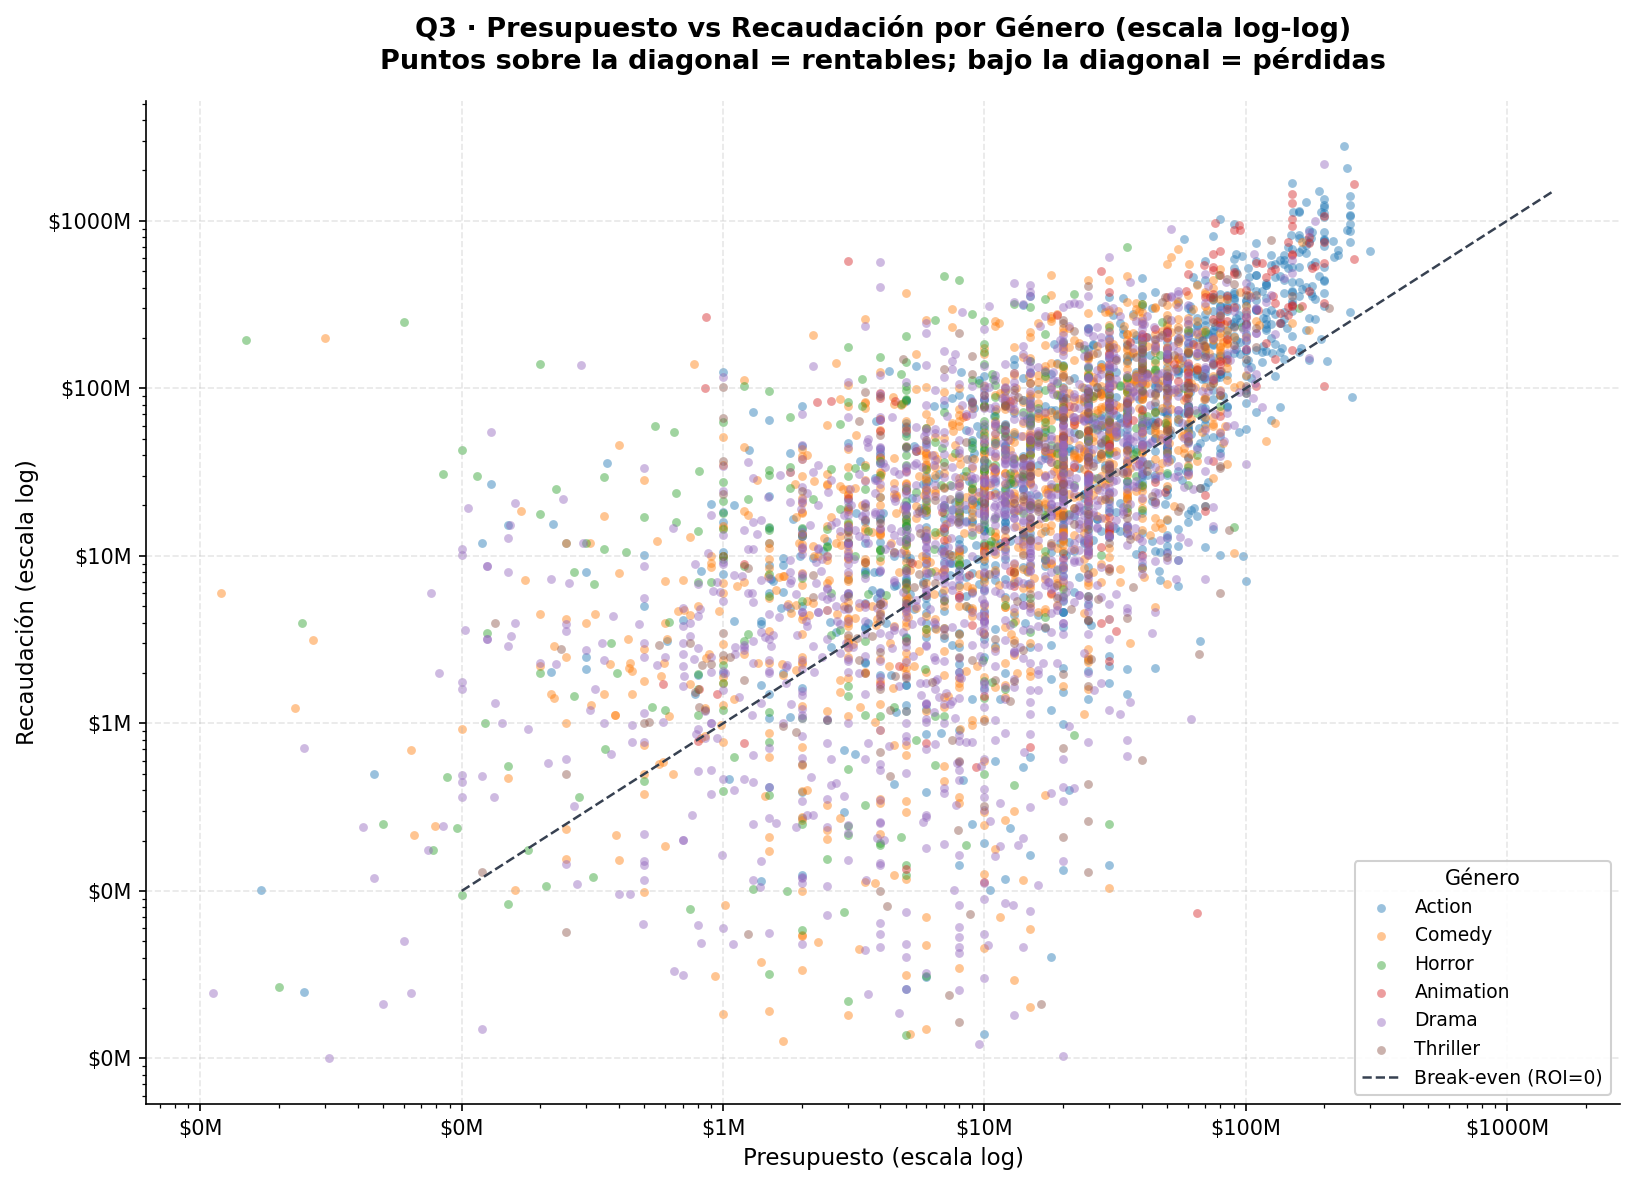

In [32]:
fig3 = plot_budget_vs_revenue(df)
plt.show()


**Interpretación:** La nube de puntos confirma una correlación positiva clara: a mayor presupuesto, mayor recaudación en términos generales. Sin embargo, la dispersión vertical es enorme; para un mismo presupuesto de 10M$ hay películas que recaudan desde 1M$ hasta 300M$, lo que demuestra que el presupuesto es condición necesaria pero no suficiente.

El hallazgo más valioso está en la esquina inferior izquierda: los puntos verdes (Horror) que aparecen muy a la izquierda del eje X pero bastante arriba en el eje Y. Son películas con presupuestos mínimos (~100K$) y recaudaciones de decenas de millones, muy por encima de la diagonal de break-even. Eso es exactamente el patrón de ROI explosivo que veíamos en Q1. Por contraste, Action se concentra en la zona de altos presupuestos donde la dispersión es menor y los puntos se acercan más a la diagonal, confirmando que es un género de rentabilidad más predecible pero menos espectacular. Por último podemos confirmar lo visto en Q1 sobre el Drama, ya que aun la mediana siendo rentable, es el género que mas se encuentra debajo o muy cerca de la daigonal.


### Q4 — ¿Las películas mejor valoradas son también las más rentables?
Scatter vote_average vs ROI (cap. percentil 95) con línea de tendencia.


[viz] Guardado → C:\Users\ferlo\Documents\evolve\MoviesEDA_FernandoLopezSanchez_DataScienceIA\figures\Q4_rating_vs_roi.png


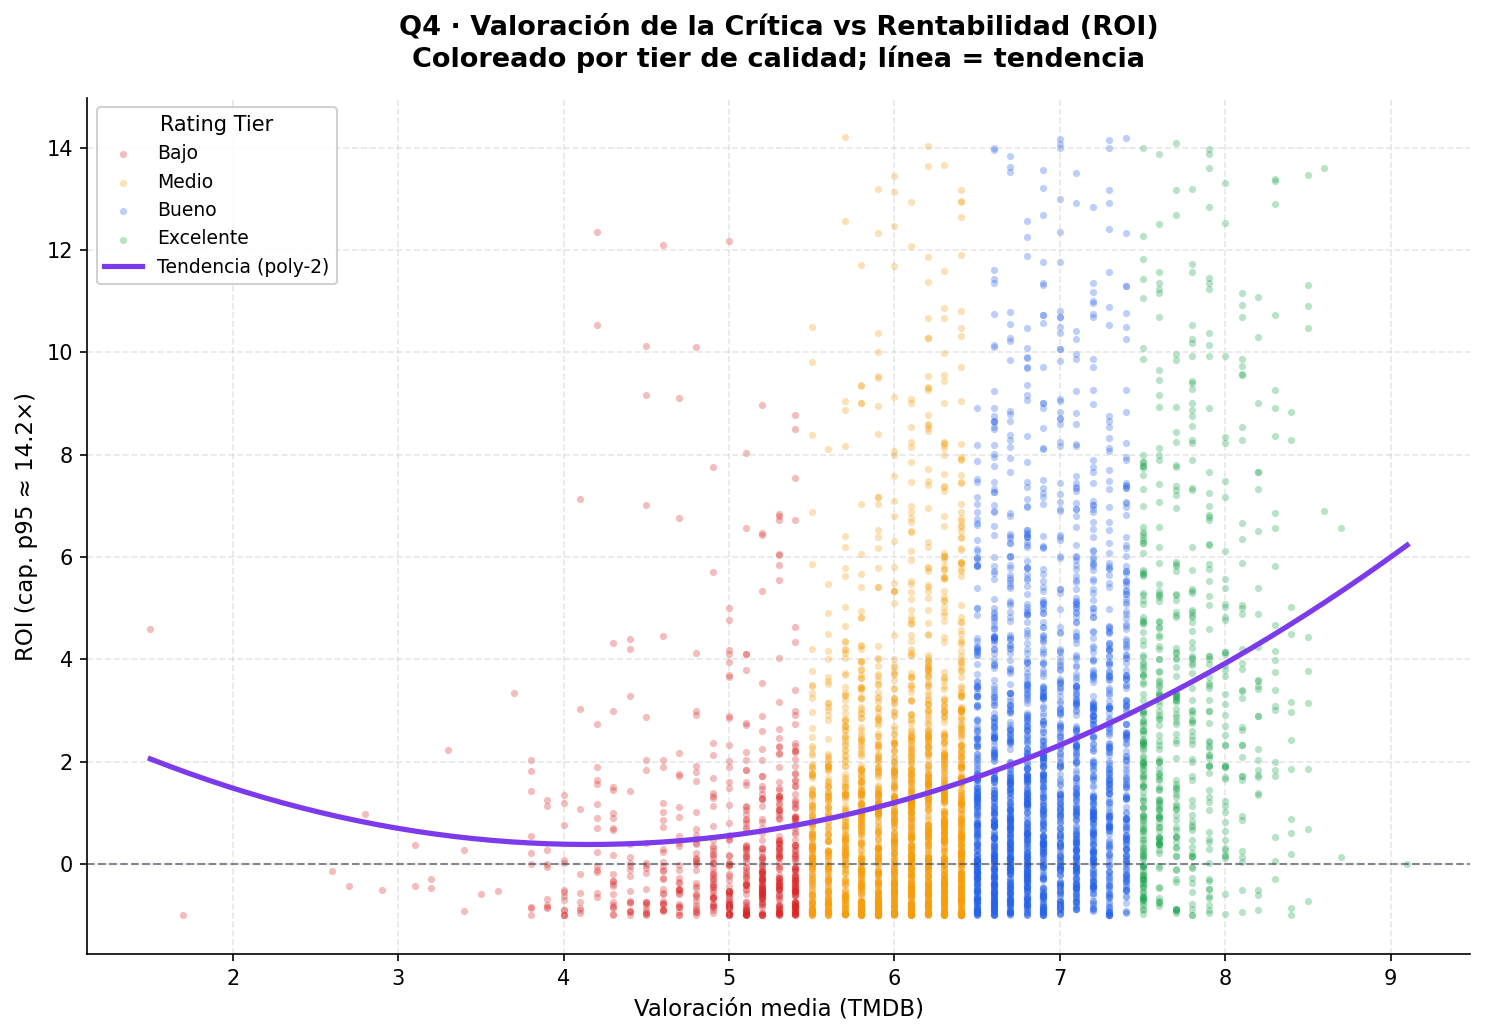

In [33]:
fig4 = plot_rating_vs_roi(df)
plt.show()


**Interpretación:** La línea de tendencia nos permite ver algo contraintuitivo: las películas peor valoradas (1-3) tienen ROI más alto que las de valoración media (4-6). La curva forma una U, tocando su mínimo alrededor del 3.5-4 de valoración y subiendo después. Esto se explica porque las películas muy malas suelen ser producciones de terror o exploitation de bajísimo presupuesto que con cualquier recaudación generan ROI alto.

A partir de valoración 7 la tendencia sube con fuerza, pero la dispersión también aumenta enormemente — hay películas excelentes (puntos verdes) tanto con ROI muy alto como con ROI negativo. La conclusión es clara: la valoración no predice la rentabilidad, y usar la puntuación de crítica como criterio de inversión sería un error estratégico.


### Q5 — ¿Qué géneros están en auge y podrían dominar la próxima década?
Evolución anual suavizada (media móvil 3 años) de 1980 a 2019.


[viz] Guardado → C:\Users\ferlo\Documents\evolve\MoviesEDA_FernandoLopezSanchez_DataScienceIA\figures\Q5_genre_trends.png


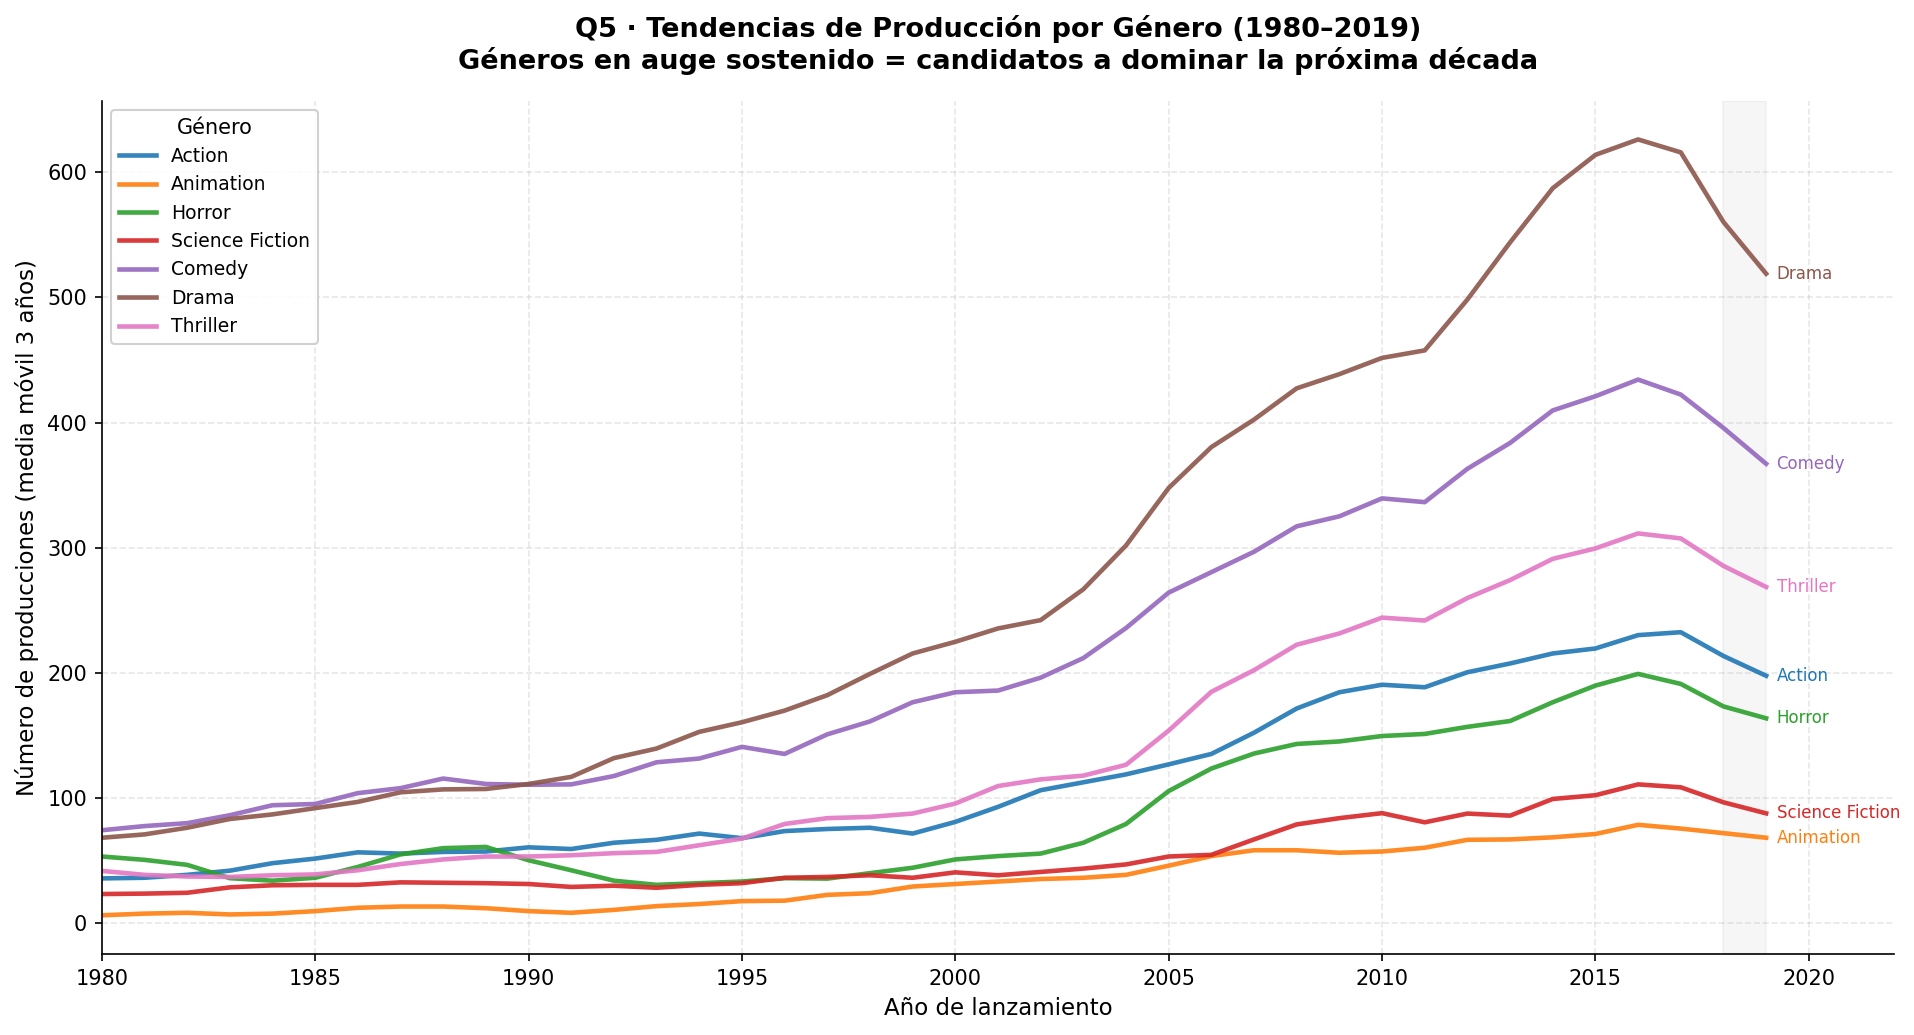

In [34]:
fig5 = plot_genre_trends(df)
plt.show()


**Interpretación:** Drama y Comedy muestran un patrón preocupante: pico alrededor de 2015-2016 seguido de caída clara. Esas fechas coinciden con el auge del streaming, podriamos deducir que ambos géneros se han visto fragmentados por ello y el interés por consumirlo ya no recae tanto en las péliculas y el cine.

Los géneros con pendiente positiva sostenida hasta 2019 sin señales de caída son Horror y Thriller, que además mantienen crecimientos constantes desde los 2000s. Animation crece lentamente pero de forma ininterrumpida desde 1985, sin ningún pico ni caída, lo que indica una demanda estructural muy estable. Combinando este gráfico con el Q1, Animation es el único género que tiene simultáneamente crecimiento sostenido de producción, ROI alto y ausencia de volatilidad, lo que lo convierte en la recomendación más sólida para inversión a largo plazo.


## 7. Exportar dataset limpio

In [35]:
export_csv(df, OUT_PATH)
print(f"\n✓ Archivo guardado en: {OUT_PATH}")
print(f"  Dimensiones: {df.shape}")


[io] Dataset exportado → C:\Users\ferlo\Documents\evolve\MoviesEDA_FernandoLopezSanchez_DataScienceIA\data\processed\clean_dataset.csv  (29,812 filas)

✓ Archivo guardado en: C:\Users\ferlo\Documents\evolve\MoviesEDA_FernandoLopezSanchez_DataScienceIA\data\processed\clean_dataset.csv
  Dimensiones: (29812, 34)


## 8. Conclusiones de Negocio

### Horror y Animation son los géneros más rentables por unidad invertida
Con ROI mediano de 145% y 164% respectivamente, superan ampliamente a los blockbusters
de Action (~103%). Un productor con presupuesto limitado maximiza su retorno apostando
por Horror o Animation de bajo coste. Sin embargo, hay que distinguir entre eficiencia
y volumen: Action y Adventure, con ROI más moderado, generan beneficios absolutos en M$
mucho mayores por el tamaño de sus producciones. La elección óptima depende del perfil
del inversor.

### La calidad crítica no se traslada a la taquilla
La correlación entre valoración TMDB y ROI es prácticamente nula (r≈0.008).
Invertir en "películas premiadas" no garantiza rentabilidad; las decisiones de inversión
deben basarse en datos financieros históricos por género, no en crítica especializada.

### Animation y Horror son los géneros con mayor potencial para la próxima década
Animation lleva 20 años de crecimiento sostenido en producción, mantiene ROI mediano
del 164% y genera beneficios absolutos consistentes. Horror combina bajo coste de
producción con audiencias fieles y en expansión. Ambos géneros son la apuesta más
sólida para carteras de inversión cinematográfica 2025-2035.

---
*Siguientes pasos: incorporar datos de streaming (Netflix, Disney+), añadir análisis
de elenco/director y construir un modelo predictivo de ROI.*